# Notebook 02 — Data Cleaning
**EPPS–American Airlines Data Challenge — GROW 26.2**

Reads raw inbound + outbound → cleans nulls, fixes types → saves to `data/processed/`

**Output files:**
- `../data/processed/inbound_clean.csv`
- `../data/processed/outbound_clean.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

INBOUND_PATH  = '../data/raw/inbound_training_table_enriched.csv'
OUTBOUND_PATH = '../data/raw/outbound_training_table_enriched.csv'
PROC_PATH     = '../data/processed/'
FIGURES_PATH  = '../outputs/figures/'
os.makedirs(PROC_PATH, exist_ok=True)
os.makedirs(FIGURES_PATH, exist_ok=True)

print('✅ Imports OK')

✅ Imports OK


## 1 — Load Raw Data

In [2]:
inbound  = pd.read_csv(INBOUND_PATH)
outbound = pd.read_csv(OUTBOUND_PATH)

# Drop fully-null rows (outbound artifact)
outbound = outbound.dropna(subset=['airport_B']).reset_index(drop=True)

print(f'Inbound  raw : {inbound.shape}')
print(f'Outbound raw : {outbound.shape}')

Inbound  raw : (276418, 46)
Outbound raw : (276904, 46)


## 2 — Fix Date Column

In [3]:
inbound['Date']  = pd.to_datetime(inbound['Date'])
outbound['Date'] = pd.to_datetime(outbound['Date'])

inbound  = inbound.sort_values('Date').reset_index(drop=True)
outbound = outbound.sort_values('Date').reset_index(drop=True)

print('Inbound  date range:', inbound['Date'].min().date(), '->', inbound['Date'].max().date())
print('Outbound date range:', outbound['Date'].min().date(), '->', outbound['Date'].max().date())

Inbound  date range: 2025-01-01 -> 2025-12-31
Outbound date range: 2025-01-01 -> 2025-12-31


## 3 — Drop High-Null Columns (≥ 90% null)

In [4]:
THRESHOLD = 0.90   # drop columns with >= 90% nulls

def drop_high_null(df, threshold, name):
    null_frac = df.isnull().mean()
    drop_cols = null_frac[null_frac >= threshold].index.tolist()
    df = df.drop(columns=drop_cols)
    print(f'{name}: dropped {len(drop_cols)} high-null cols: {drop_cols}')
    return df

inbound  = drop_high_null(inbound,  THRESHOLD, 'INBOUND')
outbound = drop_high_null(outbound, THRESHOLD, 'OUTBOUND')

print(f'\nInbound  after drop : {inbound.shape}')
print(f'Outbound after drop : {outbound.shape}')

INBOUND: dropped 4 high-null cols: ['dfw_ice_accretion', 'dfw_peak_gust_kts', 'origin_ice_accretion', 'origin_peak_gust_kts']
OUTBOUND: dropped 4 high-null cols: ['dfw_ice_accretion', 'dfw_peak_gust_kts', 'dest_ice_accretion', 'dest_peak_gust_kts']

Inbound  after drop : (276418, 42)
Outbound after drop : (276904, 42)


## 4 — Fill Remaining Nulls

In [5]:
# Inbound: fill remaining nulls with column median
null_in = inbound.isnull().sum()
null_in = null_in[null_in > 0]
print('Inbound remaining nulls before fill:')
print(null_in)
for col in null_in.index:
    med = inbound[col].median()
    inbound[col] = inbound[col].fillna(med)
    print(f'  Filled {col} with median={med:.2f}')

print()

# Outbound: fill remaining nulls with median
null_out = outbound.isnull().sum()
null_out = null_out[null_out > 0]
print('Outbound remaining nulls before fill:')
print(null_out)
for col in null_out.index:
    med = outbound[col].median()
    outbound[col] = outbound[col].fillna(med)
    print(f'  Filled {col} with median={med:.2f}')

print()
print('Inbound  nulls after fill :', inbound.isnull().sum().sum())
print('Outbound nulls after fill :', outbound.isnull().sum().sum())

Inbound remaining nulls before fill:
dfw_temp_f                 939
dfw_humidity_pct           939
dfw_wind_kts              1087
dfw_gust_kts            219809
dfw_visibility_mi          939
dfw_low_ceiling            939
dfw_thunderstorm           939
dfw_precipitation          939
dfw_freezing               939
origin_temp_f             9105
origin_humidity_pct       9191
origin_wind_kts           9700
origin_gust_kts         232275
origin_visibility_mi      9215
origin_low_ceiling        8954
origin_thunderstorm       8954
origin_precipitation      8954
origin_freezing           8954
dtype: int64
  Filled dfw_temp_f with median=73.33
  Filled dfw_humidity_pct with median=57.83
  Filled dfw_wind_kts with median=9.00
  Filled dfw_gust_kts with median=23.00
  Filled dfw_visibility_mi with median=10.00
  Filled dfw_low_ceiling with median=0.00
  Filled dfw_thunderstorm with median=0.00
  Filled dfw_precipitation with median=0.00
  Filled dfw_freezing with median=0.00
  Filled origin_te

## 5 — Fix Data Types

In [6]:
# month/weekday/is_* should be int
int_cols_in  = ['month','weekday','is_weekend','is_spring','flight_count',
                'edct_count','avg_edct_min','dfw_low_ceiling','dfw_thunderstorm',
                'dfw_precipitation','dfw_freezing','origin_low_ceiling',
                'origin_thunderstorm','origin_precipitation','origin_freezing','delayed']
int_cols_out = ['month','weekday','is_weekend','is_spring','flight_count',
                'edct_count','avg_edct_min','dfw_low_ceiling','dfw_thunderstorm',
                'dfw_precipitation','dfw_freezing','dest_low_ceiling',
                'dest_thunderstorm','dest_precipitation','dest_freezing','delayed']

for col in int_cols_in:
    if col in inbound.columns:
        inbound[col] = inbound[col].astype(int)

for col in int_cols_out:
    if col in outbound.columns:
        outbound[col] = outbound[col].astype(int)

print('Inbound dtypes fixed')
print(inbound.dtypes.to_string())
print()
print('Outbound dtypes fixed')
print(outbound.dtypes.to_string())

Inbound dtypes fixed
airport_A                       object
Date                    datetime64[ns]
month                            int64
weekday                          int64
is_weekend                       int64
season                          object
is_spring                        int64
dep_hour_A                     float64
arr_hour_DFW                   float64
flight_count                     int64
gate_dep_delay                 float64
apt_dep_delay                  float64
taxi_out_delay                 float64
avg_taxi_out                   float64
airborne_delay                 float64
taxi_in_delay                  float64
block_delay                    float64
pct_ontime_gate_dep            float64
pct_ontime_apt_dep             float64
pct_ontime_gate_arr            float64
edct_count                       int64
avg_edct_min                     int64
dfw_temp_f                     float64
dfw_humidity_pct               float64
dfw_wind_kts                   float64
dfw_

## 6 — Validate No Duplicates

In [7]:
dup_in  = inbound.duplicated().sum()
dup_out = outbound.duplicated().sum()
print(f'Inbound  duplicates : {dup_in}')
print(f'Outbound duplicates : {dup_out}')
if dup_in > 0:
    inbound = inbound.drop_duplicates().reset_index(drop=True)
    print('  → Inbound  duplicates dropped')
if dup_out > 0:
    outbound = outbound.drop_duplicates().reset_index(drop=True)
    print('  → Outbound duplicates dropped')

Inbound  duplicates : 0
Outbound duplicates : 0


## 7 — Delay Column Sanity Check

Inbound delayed:
delayed
0    150211
1    126207
Name: count, dtype: int64

Outbound delayed:
delayed
0    173497
1    103407
Name: count, dtype: int64


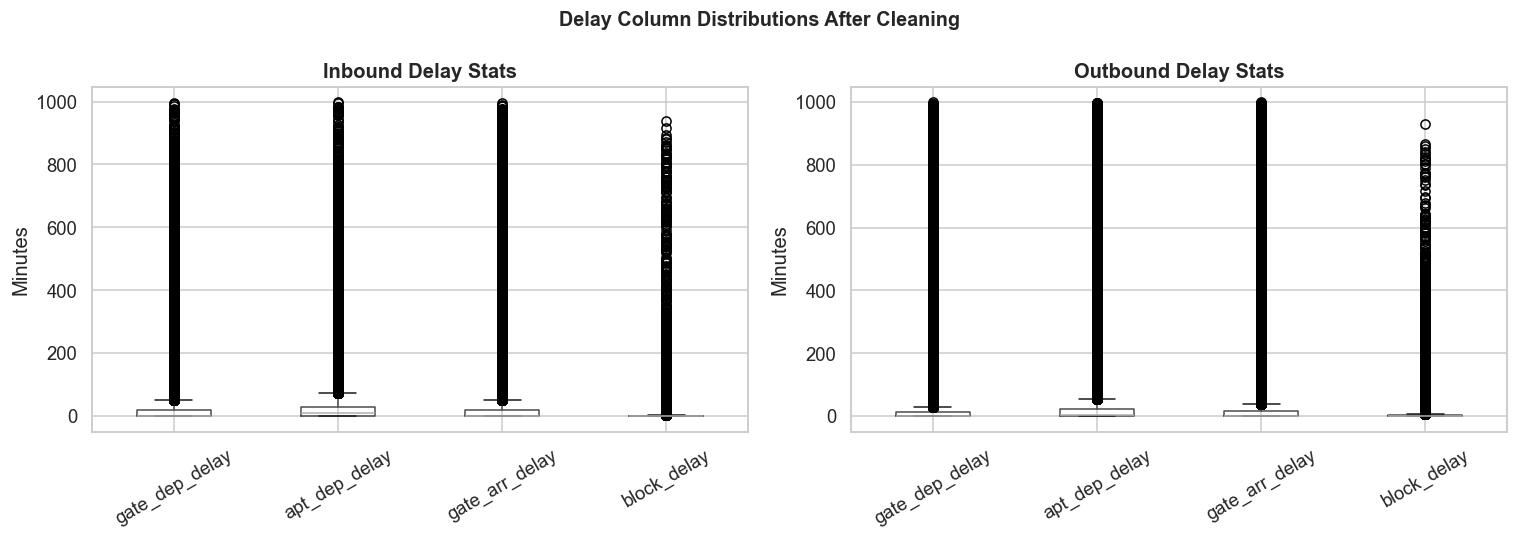

💾 12_cleaned_delay_boxplot.png


In [8]:
print('Inbound delayed:')
print(inbound['delayed'].value_counts())
print()
print('Outbound delayed:')
print(outbound['delayed'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
delay_cols_check = ['gate_dep_delay','apt_dep_delay','gate_arr_delay','block_delay']

for ax, df, title in zip(axes, [inbound, outbound],
                         ['Inbound Delay Stats','Outbound Delay Stats']):
    avail = [c for c in delay_cols_check if c in df.columns]
    df[avail].boxplot(ax=ax, vert=True)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Minutes')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Delay Column Distributions After Cleaning', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}12_cleaned_delay_boxplot.png', bbox_inches='tight')
plt.show()
print('💾 12_cleaned_delay_boxplot.png')

## 8 — Final Shape & Save

In [9]:
print('=== FINAL SHAPES ===')
print(f'Inbound  : {inbound.shape}')
print(f'Outbound : {outbound.shape}')
print(f'Inbound  nulls: {inbound.isnull().sum().sum()}')
print(f'Outbound nulls: {outbound.isnull().sum().sum()}')

inbound.to_csv(f'{PROC_PATH}inbound_clean.csv',  index=False)
outbound.to_csv(f'{PROC_PATH}outbound_clean.csv', index=False)

print()
print('💾 Saved → data/processed/inbound_clean.csv')
print('💾 Saved → data/processed/outbound_clean.csv')
print()
print('✅ Next → Notebook 03: Feature Engineering')

=== FINAL SHAPES ===
Inbound  : (276418, 42)
Outbound : (276904, 42)
Inbound  nulls: 0
Outbound nulls: 0

💾 Saved → data/processed/inbound_clean.csv
💾 Saved → data/processed/outbound_clean.csv

✅ Next → Notebook 03: Feature Engineering
